In [3573]:
from matplotlib import pyplot as plt
import numpy as np

In [3574]:
try:
    import keras
    import tensorflow
except:
    !pip install keras_preprocessing
    !pip install keras
    !pip install tensorflow
    import keras
    import tensorflow

In [3575]:
import keras
import tensorflow

In [3576]:
from keras_preprocessing import image as img

In [3577]:
from PIL import Image

In [3578]:
from keras.preprocessing.image import img_to_array

# Visão de escalabilidade e requisitos

Text(0, 0.5, 'Requisito Systolic')

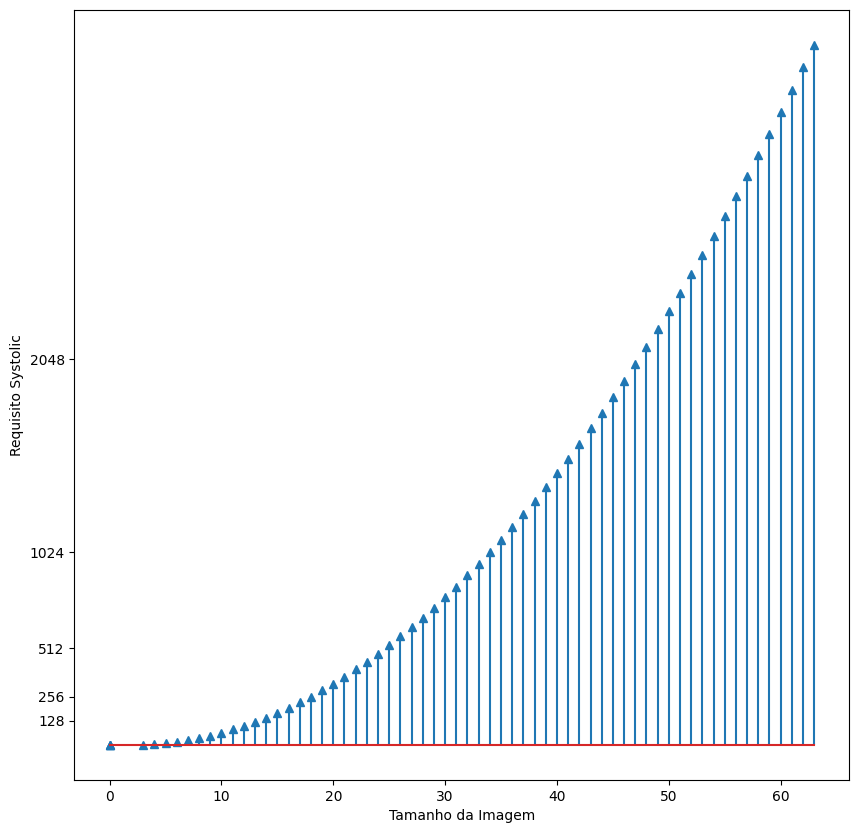

In [3618]:
sizt =64
sizek = 3
sizeSystolicCore = np.zeros(sizt)
sizeImagemProcessada = np.zeros(sizt)

for i in range(sizek,sizt):
    #(Imagem-1)**2==Systolic
    sizeImagemProcessada[i-sizek] =i
    sizeSystolicCore[i-sizek] = 2**(np.log2((i-sizek+1)**2))

plt.figure(figsize=(10,10))
desl = 7
plt.yticks([2**(i+desl) for i in range(sizt-desl)])
plt.stem(sizeImagemProcessada,sizeSystolicCore,markerfmt="^")
plt.xlabel("Tamanho da Imagem")
plt.ylabel("Requisito Systolic")

In [3580]:
K1 = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
K2 = np.array([[-1,0,-1],[-2,0,2],[-1,0,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K2=K1
M = np.array([[1,2,3,4],[4,5,6,4],[7,8,9,4],[3,6,0,1]])

M = np.array([[1,2,3],[4,5,6],[7,8,9]])
#K = np.array([[1,0],[0,-1]])
#K = np.array([[0,0],[0,1]])


In [3581]:
path = "./Monalisa.webp"
image =plt.imread(path)

In [3582]:

imga = img.load_img(
    path,
    target_size=(sizt,sizt),
    color_mode="grayscale",

)

In [3583]:
image = imga.resize([sizt, sizt])



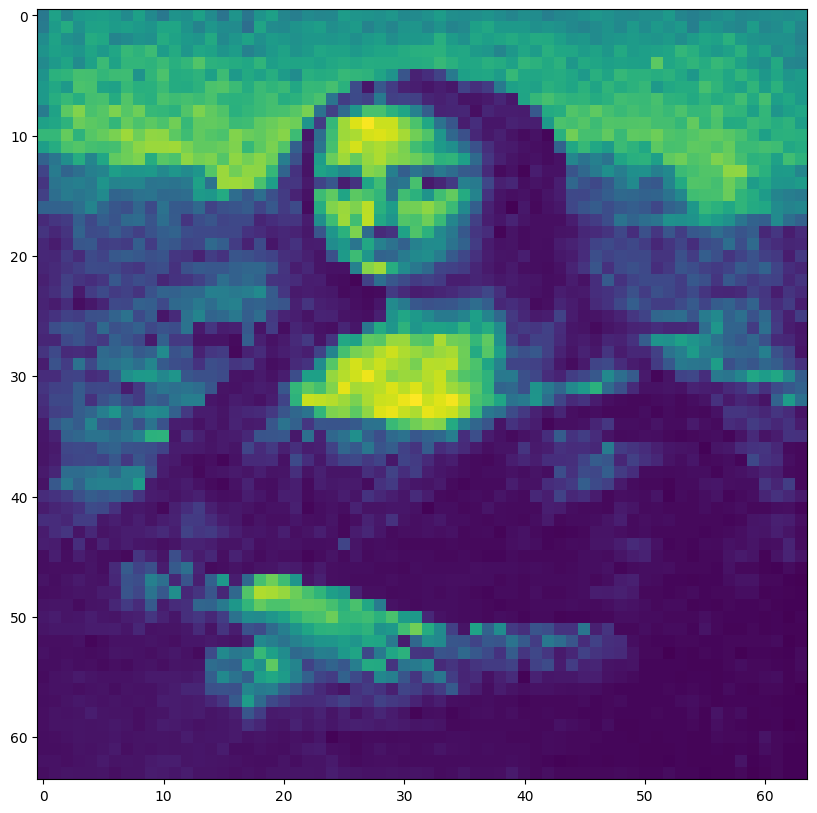

In [3636]:
IMAG = img_to_array(image).reshape(sizt,sizt)
plt.figure(figsize=(10,10))
plt.imshow(IMAG)
#IMAG = M

In [3586]:
def flatten_kernel(K):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada somente no kernel'''

    size = K.shape[0]
    outK = np.zeros((1,size**2))
    k = 0
    for i in range (size):
        for j in range(size):
        
            outK[0][k] = K[i][j]
            k+=1
    return outK

In [3587]:
def inv_transform(M,sizeMinicial):
    "Inversão das transformações"
    size = int((sizeMinicial))
    Mout = np.zeros((size,size))
    print(size)

    k = 0
    for i in range(size):
        for j in range(size):
            Mout[i][j] = M[0][k]

            k+=1

    return Mout



In [3637]:
def transform_matrix(M,Kern):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada matriz de entra'''
    sizeKernel  = Kern.shape[0] 
    sizel = M.shape[0]
    sizec = M.shape[1]
    Mout = np.zeros((sizeKernel**2,int((sizel-sizeKernel+1)**2)))
    k = 0
    for i in range(0,sizel-sizeKernel+1):
        for j in range(0,sizec-sizeKernel+1):
            '''Melhorias futuras'''
            X0 ,X1 ,X2 ,X3 ,X4 ,X5 ,X6 ,X7 ,X8 = M[i][j],M[i][j+1],M[i][j+2],M[i+1][j+0],M[i+1][j+1],M[i+1][j+2],M[i+2][j+0],M[i+2][j+1],M[i+2][j+2]
            #X8 ,X7 ,X6 ,X5 ,X4 ,X3 ,X2 ,X1 ,X0 = M[i][j],M[i][j+1],M[i][j+2],M[i+1][j+0],M[i+1][j+1],M[i+1][j+2],M[i+2][j+0],M[i+2][j+1],M[i+2][j+2]
            Mout[0][k+0] = X0
            Mout[1][k+0] = X1
            Mout[2][k+0] = X2
            Mout[3][k+0] = X3
            Mout[4][k+0] = X4
            Mout[5][k+0] = X5
            Mout[6][k+0] = X6
            Mout[7][k+0] = X7
            Mout[8][k+0] = X8

            #X0 ,X1 ,X2 ,X3 = M[i][j],M[i][j+1],M[i+1][j],M[i+1][j+1]
            #Mout[0+0][k+0] = X0
            #Mout[0+1][k+0] = X1
            #Mout[0+2][k+0] = X2
            #Mout[0+3][k+0] = X3

            #print(X0,X1,X2,X3)

            k+=1
    return Mout

In [3589]:
def normalizeMatrixSIZE(matrix,sizeTarget):
    matrixMout = np.zeros((sizeTarget,sizeTarget))
    size_row = matrix.shape[1]
    size_lin = matrix.shape[0]
    for i in range(size_lin):
        for j in  range(size_row):
            matrixMout[i][j] = matrix[i][j]
            #print("Aqui",matrix[i][j])
    return matrixMout
    


In [3590]:
def conv2mult(sizeTarget, inputConv,inputK):
    '''Esta função realizá as transformações necessárias para converter a operação de convolução em uma multiplicação de matrizes'''
    Matrix_tranform = transform_matrix(inputConv,inputK)
    Kernel_transform = flatten_kernel(inputK)
    matrix_target_image=normalizeMatrixSIZE(matrix=Matrix_tranform,sizeTarget =sizeTarget)
    matrix_target_kernel=normalizeMatrixSIZE(matrix=Kernel_transform,sizeTarget=sizeTarget)
    return (matrix_target_kernel,matrix_target_image)

### Kernel no domíno base

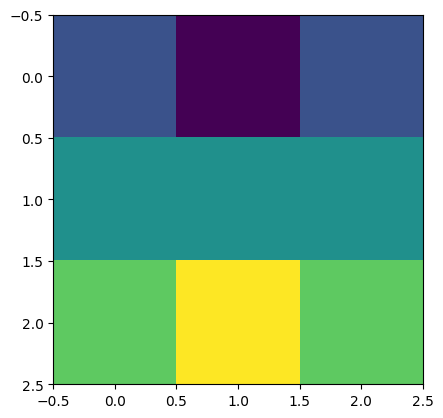

In [3629]:
plt.imshow(K1)

### Imagem no domínio base

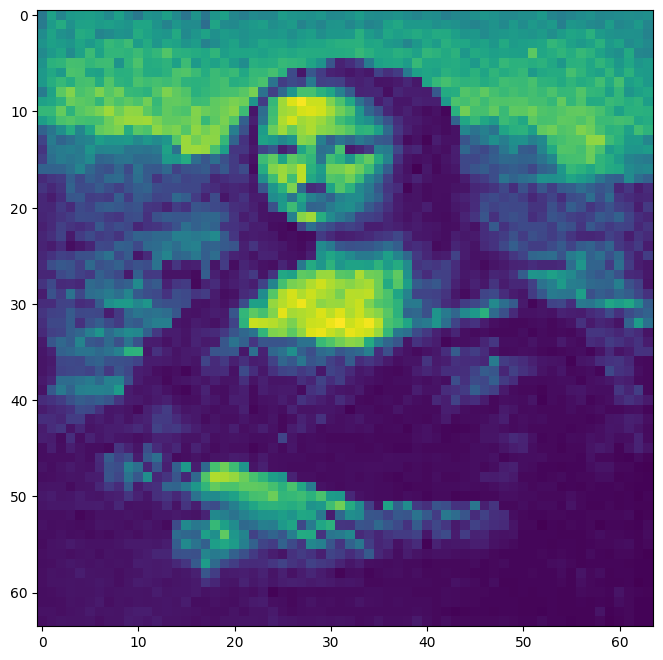

In [3628]:
plt.figure(figsize=(8,8))
plt.imshow(IMAG)

In [3593]:
#plt.figure(figsize=(500,1000))
#plt.imshow(transform_matrix(IMAG,Kern=K).T)

In [3594]:
requi = 2**int(np.log2((IMAG.shape[0]-sizek)**2)+1)
print("Requisito do multiplicador:", requi)

Requisito do multiplicador: 4096


In [3595]:
A1,B1 = conv2mult(sizeTarget=requi,inputConv=IMAG,inputK=K1)
A2,B2 = conv2mult(sizeTarget=requi,inputConv=IMAG,inputK=K2)

## Kernel no novo domínio com expansão dos operandos

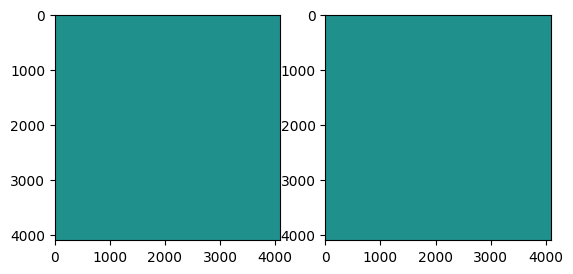

In [3596]:
plt.subplot(1,2,1)
plt.imshow(A1)
plt.subplot(1,2,2)
plt.imshow(A2)

## Imagem no novo domínio com expansão dos operandos


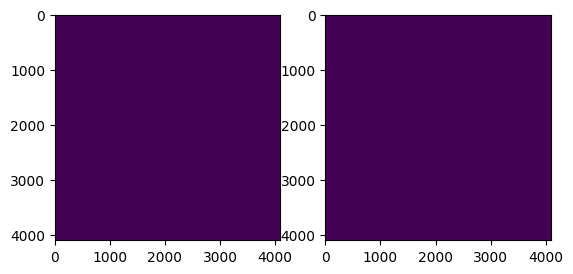

In [3597]:
plt.subplot(1,2,1)
plt.imshow(B1)
plt.subplot(1,2,2)
plt.imshow(B2)


In [3598]:
Mout_vec1 = A1@B1
Mout_vec2 = A2@B2

#Resultado da Convolução no novo domínio com expansão dos operandos

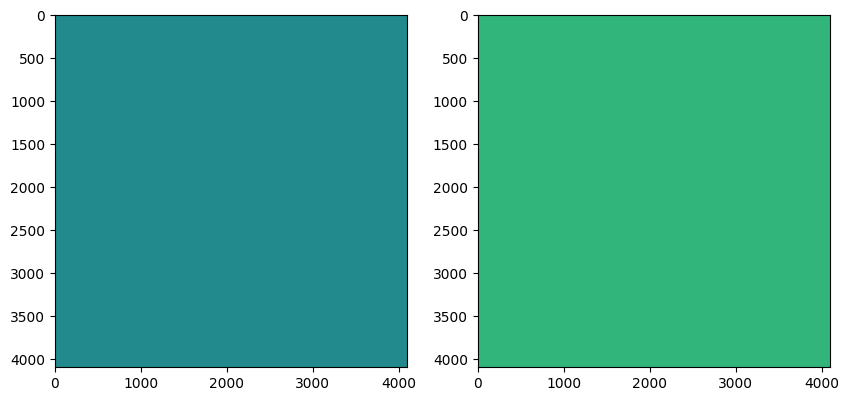

In [3599]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(Mout_vec1)
plt.subplot(1,2,2)
plt.imshow(Mout_vec2)
plt.show()

#Resultado da Convolução no domínio base

In [3600]:
Mout_vec1[:][0].shape

(4096,)

In [3601]:
inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))

62


array([[-102., -283., -218., ..., -243., -186., -244.],
       [-212., -283., -208., ..., -244., -235., -239.],
       [-182., -266., -235., ..., -231., -258., -250.],
       ...,
       [ -23.,  -22.,  -27., ...,  -11.,  -31.,  -21.],
       [ -25.,  -23.,  -25., ...,  -10.,  -37.,  -25.],
       [ -23.,  -26.,  -24., ...,   -6.,  -23.,  -24.]], shape=(62, 62))

62
62


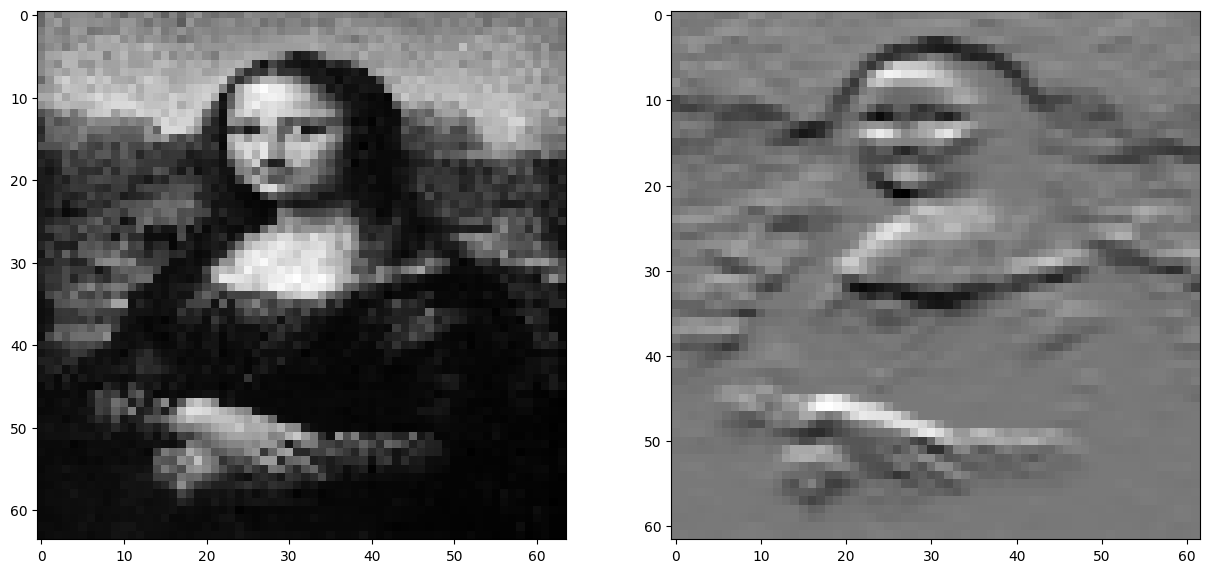

In [3602]:
cmap = "gray"
Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
plt.figure(figsize=(15,15))
plt.subplot(1,2,2)
plt.imshow(Mout1,cmap=cmap)
plt.subplot(1,2,1)
plt.imshow(IMAG,cmap=cmap)
plt.show()

62
62


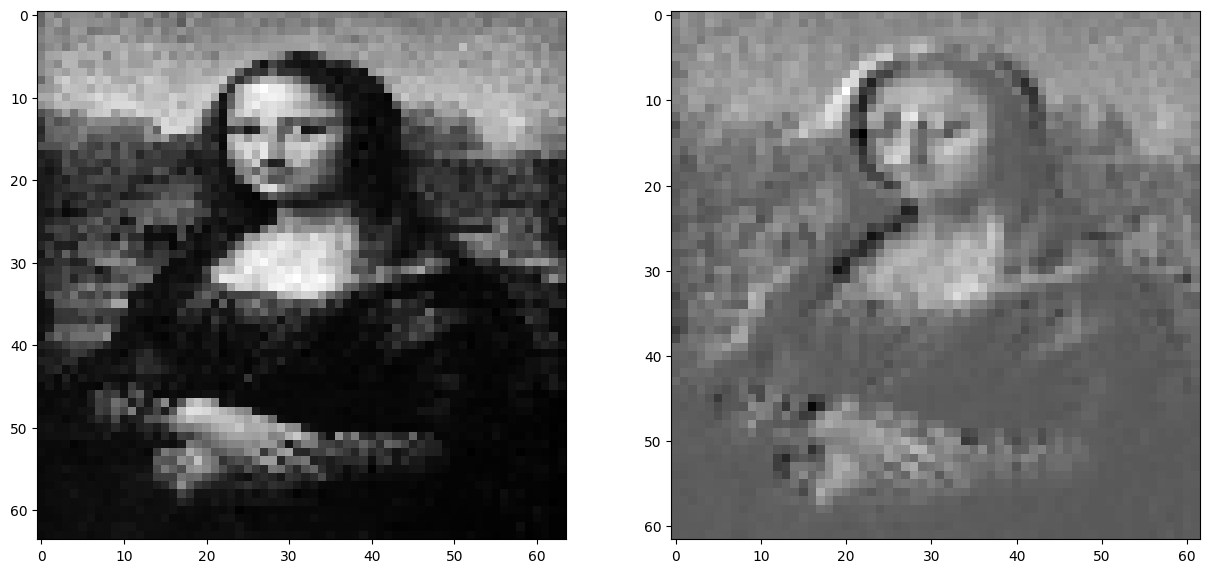

In [3624]:
cmap1 = "gray"
cmap2= "binary"
Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
plt.figure(figsize=(15,15))
plt.subplot(1,2,2)
plt.imshow(Mout2,cmap=cmap2)
plt.subplot(1,2,1)
plt.imshow(IMAG,cmap=cmap1)
plt.show()

62
62


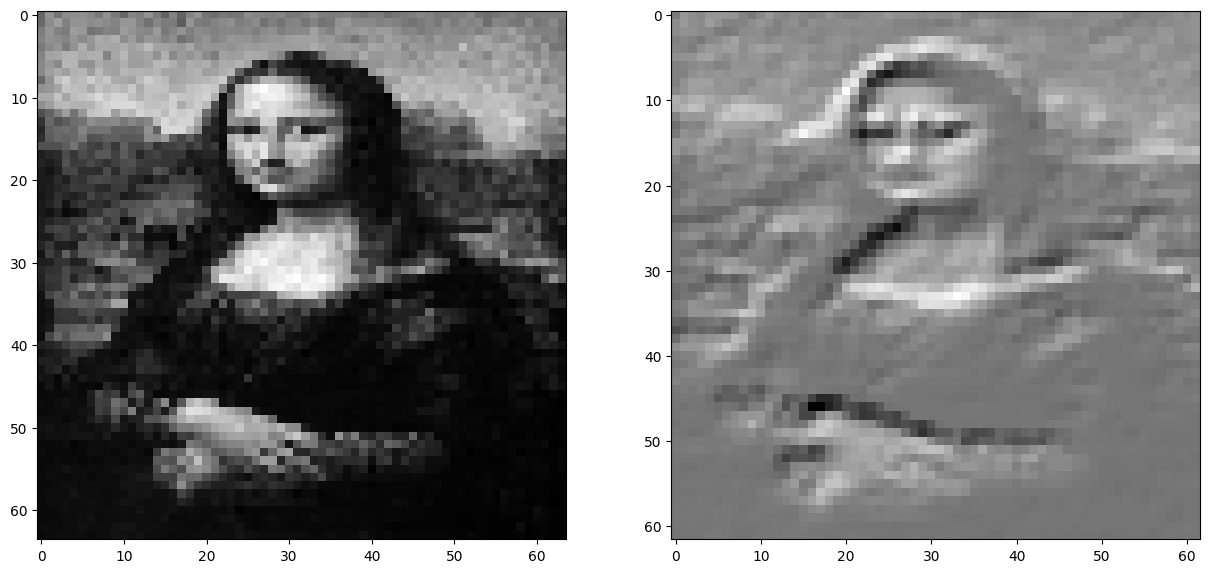

In [3625]:
cmap1 = "gray"
cmap2= "binary"
Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
plt.figure(figsize=(15,15))
plt.subplot(1,2,2)
plt.imshow(Mout2+Mout1,cmap=cmap2)
plt.subplot(1,2,1)
plt.imshow(IMAG,cmap=cmap1)
plt.show()